<a href="https://colab.research.google.com/github/candearra45/tpo-ciencia-datos-formula-del-hit/blob/main/TPO_LaFormulaDelHit_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎵 La Fórmula del Hit — Notebook (Colab)
### ¿Tiene el éxito en contenido corto (TikTok/Reels/Shorts) una huella de audio medible?
**TPO Ciencia de Datos — UADE 2026** · Datasets: Spotify + TikTok (Kaggle)

Este notebook está organizado en **4 etapas**:
1. **Limpieza** — cargar, deduplicar, crear `es_hit` y la bandera `en_tiktok` (cruce Spotify×TikTok)
2. **EDA** — distribuciones, correlaciones, perfil del hit y del tema de TikTok, capa cultural
3. **Modelo** — RandomForest + validación honesta (control de género/popularidad), lift de negocio
4. **App** — sliders de audio → score de *Potencial Short-Content*

> Corré las celdas **en orden, de arriba hacia abajo**. La Etapa 0 carga los datos.

## ⚙️ Etapa 0 — Setup y carga de datos

Necesitás los dos CSV: `spotify_tracks.csv` y `tiktok_trending.csv`.
Elegí **una** de las dos opciones de abajo (la celda detecta sola si ya están).

In [ ]:
# Imports
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
print("Librerías OK")

Librerías OK


In [ ]:
# --- Carga de datos: 3 opciones ---
import os
SPOTIFY_PATH = "spotify_tracks.csv"
TIKTOK_PATH  = "tiktok_trending.csv"

def _exists(): return os.path.exists(SPOTIFY_PATH) and os.path.exists(TIKTOK_PATH)

if not _exists():
    try:
        # Estamos en Colab -> subir manualmente los 2 CSV
        from google.colab import files
        print("Subí los DOS archivos: spotify_tracks.csv y tiktok_trending.csv")
        up = files.upload()
        for name in up:
            low = name.lower()
            if "spotify" in low: SPOTIFY_PATH = name
            elif "tiktok" in low: TIKTOK_PATH = name
    except Exception as e:
        print("No es Colab o no se subieron archivos:", e)

# Opción alternativa (descomentar): montar Google Drive
# from google.colab import drive; drive.mount("/content/drive")
# SPOTIFY_PATH = "/content/drive/MyDrive/TP/spotify_tracks.csv"
# TIKTOK_PATH  = "/content/drive/MyDrive/TP/tiktok_trending.csv"

assert _exists(), "Faltan los CSV. Subilos o ajustá las rutas."
print("Datos encontrados ✓")

Datos encontrados ✓


## 🧹 Etapa 1 — Limpieza y preparación (`01_limpieza`)

- Deduplicamos Spotify por `track_id` (el dataset trae cada tema repetido en varios géneros: 114k filas → ~89.7k únicas).
- `duration_ms` → minutos.
- `es_hit` = `popularity ≥ 70`.
- **Cruce** Spotify×TikTok por `track_id` → bandera `en_tiktok`.

In [ ]:
# Cargar
sp = pd.read_csv(SPOTIFY_PATH)
tk = pd.read_csv(TIKTOK_PATH)
print("Spotify:", sp.shape, "| TikTok:", tk.shape)

# Dedup Spotify por track_id (popularity es constante por track)
spu = sp.drop_duplicates(subset="track_id").copy()
spu["dur_min"] = spu["duration_ms"] / 60000

# Target hit
spu["es_hit"] = (spu["popularity"] >= 70).astype(int)

# Cruce por track_id -> en_tiktok
tk_ids = set(tk["track_id"].dropna().unique())
spu["en_tiktok"] = spu["track_id"].isin(tk_ids).astype(int)

# TikTok deduplicado (para comparar perfiles)
tku = tk.drop_duplicates(subset="track_id").copy()
tku["dur_min"] = tku["duration_mins"] if "duration_mins" in tku else tku["duration"]/60000

print(f"Spotify únicas: {spu.shape[0]:,} | TikTok únicas: {tku.shape[0]:,}")
print(f"Hits (pop>=70): {spu['es_hit'].mean()*100:.2f}%  ({spu['es_hit'].sum():,} temas)")
print(f"Cruce en_tiktok (match track_id): {spu['en_tiktok'].sum():,} temas")
spu.head(3)

Spotify: (114000, 21) | TikTok: (6746, 23)
Spotify únicas: 89,741 | TikTok únicas: 3,560
Hits (pop>=70): 3.48%  (3,126 temas)
Cruce en_tiktok (match track_id): 401 temas


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,dur_min,es_hit,en_tiktok
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,0.032,0.000,0.358,0.715,87.917,4,acoustic,3.844,1,0
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,0.924,0.000,0.101,0.267,77.489,4,acoustic,2.494,0,0
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,...,0.210,0.000,0.117,0.120,76.332,4,acoustic,3.514,0,0


## 📊 Etapa 2 — Análisis Exploratorio (`02_eda`)

Hallazgos clave: el target está muy desbalanceado, las correlaciones lineales audio↔popularidad son débiles,
el hit es más fuerte/menos acústico, y el tema de TikTok tiene un perfil propio (más bailable, más corto, más hablado).

es_hit (pop>=70): 3.48%
popularity == 0 : 10.53%


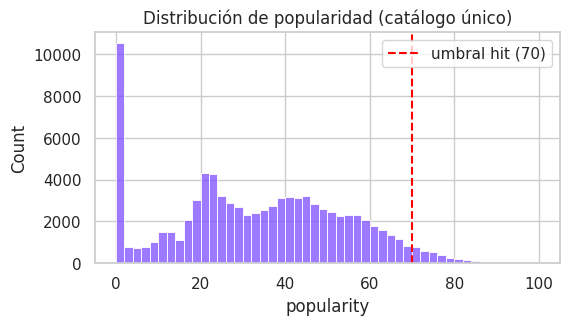

In [ ]:
# 2.1 Desbalance del target
print(f"es_hit (pop>=70): {spu['es_hit'].mean()*100:.2f}%")
print(f"popularity == 0 : {(spu['popularity']==0).mean()*100:.2f}%")

plt.figure(figsize=(6,3))
sns.histplot(spu["popularity"], bins=50, color="#7c4dff")
plt.axvline(70, color="red", ls="--", label="umbral hit (70)")
plt.title("Distribución de popularidad (catálogo único)"); plt.legend(); plt.show()

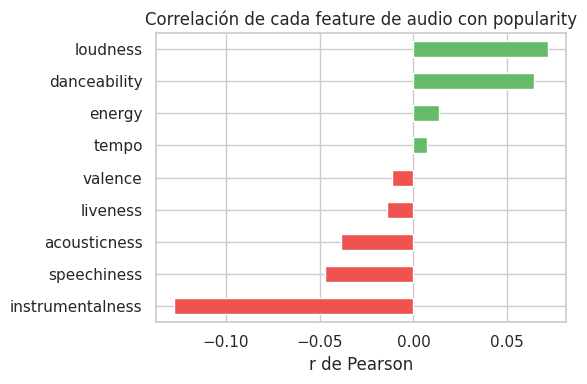

Máx |r| = 0.127 -> no hay 'fórmula' lineal


In [ ]:
# 2.2 Correlaciones audio <-> popularidad (todas débiles)
audio = ["danceability","energy","loudness","speechiness","acousticness",
         "instrumentalness","liveness","valence","tempo"]
cors = spu[audio+["popularity"]].corr()["popularity"].drop("popularity").sort_values()
plt.figure(figsize=(6,4))
cors.plot(kind="barh", color=np.where(cors<0,"#ef5350","#66bb6a"))
plt.title("Correlación de cada feature de audio con popularity")
plt.xlabel("r de Pearson"); plt.tight_layout(); plt.show()
print("Máx |r| =", round(cors.abs().max(),3), "-> no hay 'fórmula' lineal")

,catálogo,hit Spotify (pop>=70),TikTok
danceability,0.562,0.622,0.728
energy,0.634,0.664,0.637
loudness,-8.499,-6.731,-6.967
acousticness,0.328,0.230,0.211
speechiness,0.087,0.080,0.136
valence,0.469,0.511,0.538
dur_min,3.819,3.624,3.246


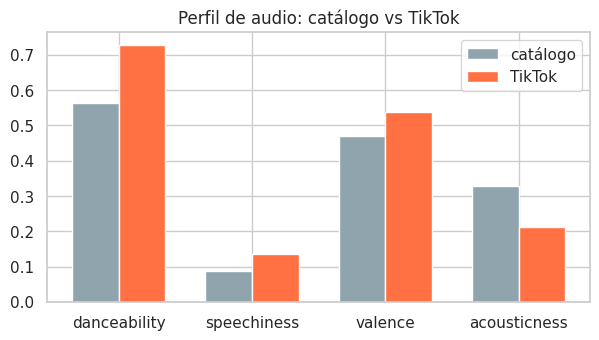

In [ ]:
# 2.3 Hit vs catálogo + perfil TikTok (tabla comparativa)
hit = spu[spu["es_hit"]==1]
feats = ["danceability","energy","loudness","acousticness","speechiness","valence","dur_min"]
tabla = pd.DataFrame({
    "catálogo": spu[feats].mean(),
    "hit Spotify (pop>=70)": hit[feats].mean(),
    "TikTok": tku[feats].mean(),
})
display(tabla.round(3))

# Gráfico del perfil TikTok vs catálogo (features normalizadas 0-1)
comp = ["danceability","speechiness","valence","acousticness"]
xt = np.arange(len(comp)); w=0.35
plt.figure(figsize=(7,3.5))
plt.bar(xt-w/2, spu[comp].mean(), w, label="catálogo", color="#90a4ae")
plt.bar(xt+w/2, tku[comp].mean(), w, label="TikTok", color="#ff7043")
plt.xticks(xt, comp); plt.title("Perfil de audio: catálogo vs TikTok"); plt.legend(); plt.show()

== Explícito ==
  catálogo: 8.6%  |  en hits: 17.9%

== Top géneros por popularidad media ==


,popularity
track_genre,
k-pop,59.400
pop-film,59.100
metal,56.400
chill,53.700
latino,51.800
sad,51.100
grunge,50.600
indian,49.800


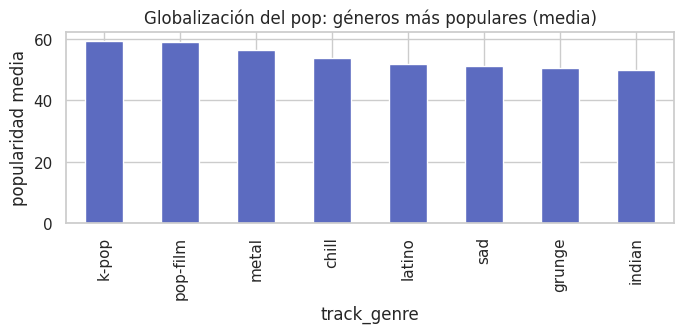

In [ ]:
# 2.4 Capa cultural
print("== Explícito ==")
print(f"  catálogo: {spu['explicit'].mean()*100:.1f}%  |  en hits: {hit['explicit'].mean()*100:.1f}%")

print("\n== Top géneros por popularidad media ==")
gpop = spu.groupby("track_genre")["popularity"].mean().sort_values(ascending=False)
display(gpop.head(8).round(1))

plt.figure(figsize=(7,3.5))
gpop.head(8).plot(kind="bar", color="#5c6bc0")
plt.title("Globalización del pop: géneros más populares (media)")
plt.ylabel("popularidad media"); plt.tight_layout(); plt.show()

## 🤖 Etapa 3 — Modelado y validación honesta (`03_modelo`)

Entrenamos un **RandomForest** (`class_weight='balanced'`) y validamos con **cross-validation 5-fold** usando **AUC** (la métrica correcta con clases desbalanceadas, igual que Herremans et al.).

**Lo importante (rigor):** el AUC del catálogo completo está inflado por *clasificación de género accidental*. Lo controlamos midiendo el AUC **dentro de hits** (saca el efecto popularidad) y **dentro de géneros afines** (saca el efecto género). El número honesto es el controlado.

> ⚠️ Estos números se recalculan en vivo. Si difieren del documento, **vale el output del notebook** — es la fuente de verdad.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import average_precision_score, confusion_matrix, RocCurveDisplay

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
FEAT = ["danceability","energy","loudness","speechiness","acousticness",
        "instrumentalness","liveness","valence","tempo","dur_min"]

def auc_cv(df, target, feats=FEAT):
    X = df[feats].fillna(df[feats].median()); y = df[target]
    if y.nunique() < 2: return float("nan")
    rf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                random_state=42, n_jobs=-1)
    return cross_val_score(rf, X, y, cv=cv, scoring="roc_auc").mean()

print("Entrenando (puede tardar ~1-2 min)...")
print(f"AUC predecir es_hit (Spotify)          : {auc_cv(spu,'es_hit'):.3f}")
print(f"AUC predecir en_tiktok (catálogo, naive): {auc_cv(spu,'en_tiktok'):.3f}")

Entrenando (puede tardar ~1-2 min)...
AUC predecir es_hit (Spotify)          : 0.712
AUC predecir en_tiktok (catálogo, naive): 0.709


In [ ]:
# Control de confounds
print("== Validación honesta — controlando confounds ==")
naive = auc_cv(spu, "en_tiktok")
ctrl_pop  = auc_cv(spu[spu["es_hit"]==1], "en_tiktok")          # solo entre hits (saca popularidad)
afines = ["dance","edm","pop","latino","latin","reggaeton","hip-hop","r-n-b","k-pop"]
sub_g = spu[spu["track_genre"].isin(afines)]
ctrl_gen  = auc_cv(sub_g, "en_tiktok")                           # dentro de géneros afines (saca género)
print(f"  naive (catálogo completo)        : {naive:.3f}")
print(f"  dentro de hits (control pop)     : {ctrl_pop:.3f}")
print(f"  dentro de géneros afines (n={len(sub_g):,}): {ctrl_gen:.3f}")
print("\nNota: el control de género es sensible a QUÉ géneros se incluyen. Probar variantes.")

== Validación honesta — controlando confounds ==
  naive (catálogo completo)        : 0.709
  dentro de hits (control pop)     : 0.646
  dentro de géneros afines (n=5,537): 0.701

Nota: el control de género es sensible a QUÉ géneros se incluyen. Probar variantes.


PR-AUC (en_tiktok): 0.017  (base=0.004)


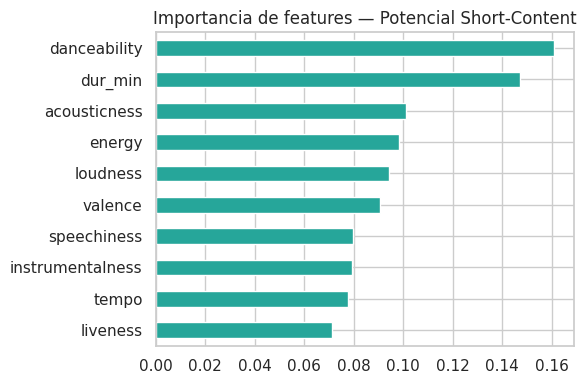

In [ ]:
# Importancia de features + PR-AUC + matriz de confusión (target en_tiktok)
X = spu[FEAT].fillna(spu[FEAT].median()); y = spu["en_tiktok"]
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
proba = cross_val_predict(rf, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:,1]
print(f"PR-AUC (en_tiktok): {average_precision_score(y, proba):.3f}  (base={y.mean():.3f})")

rf.fit(X, y)
imp = pd.Series(rf.feature_importances_, index=FEAT).sort_values()
plt.figure(figsize=(6,4)); imp.plot(kind="barh", color="#26a69a")
plt.title("Importancia de features — Potencial Short-Content"); plt.tight_layout(); plt.show()

In [ ]:
# Lift de negocio: rankear por prob de es_hit y medir tasa de hit en top-k
Xh = spu[FEAT].fillna(spu[FEAT].median()); yh = spu["es_hit"]
rfh = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
ph = cross_val_predict(rfh, Xh, yh, cv=cv, method="predict_proba", n_jobs=-1)[:,1]
order = np.argsort(-ph); base = yh.mean()
print(f"Base de hits: {base*100:.1f}%\n")
rows=[]
for pct in [0.01,0.05,0.10,0.20]:
    k=int(len(order)*pct); rate=yh.iloc[order[:k]].mean()
    capt=yh.iloc[order[:k]].sum()/yh.sum()
    rows.append([f"top {int(pct*100)}%", f"{rate*100:.1f}%", f"x{rate/base:.1f}", f"{capt*100:.0f}%"])
display(pd.DataFrame(rows, columns=["Revisa el…","tasa de hits","lift","captura de hits"]))

Base de hits: 3.5%



,Revisa el…,tasa de hits,lift,captura de hits
0,top 1%,10.1%,x2.9,3%
1,top 5%,11.7%,x3.4,17%
2,top 10%,10.1%,x2.9,29%
3,top 20%,7.9%,x2.3,45%


In [ ]:
# (Opcional) Comparación con Regresión Logística (la ganadora de Herremans, más interpretable)
logit = make_pipeline(StandardScaler(),
                      LogisticRegression(class_weight="balanced", max_iter=1000))
Xl = spu[FEAT].fillna(spu[FEAT].median())
auc_logit = cross_val_score(logit, Xl, spu["en_tiktok"], cv=cv, scoring="roc_auc").mean()
print(f"AUC Logística (en_tiktok, catálogo): {auc_logit:.3f}")

AUC Logística (en_tiktok, catálogo): 0.784


## 🎛️ Etapa 4 — App interactiva (`04_app`)

Entrenamos el modelo final y exponemos **sliders** de audio. Movés los valores y obtenés un
**score de Potencial Short-Content (0–100%)** + las features que más pesan.

> En Colab los `ipywidgets` funcionan directo. Si no ves los sliders, ejecutá la celda de nuevo.

In [ ]:
try:
    import ipywidgets as widgets
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets as widgets
from IPython.display import display, clear_output

# Modelo final sobre todo el catálogo
APP_FEAT = ["danceability","energy","loudness","speechiness","acousticness","valence","dur_min"]
Xa = spu[APP_FEAT].fillna(spu[APP_FEAT].median())
model = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
model.fit(Xa, spu["en_tiktok"])

defaults = Xa.median()
sliders = {
    "danceability": widgets.FloatSlider(value=float(defaults["danceability"]), min=0, max=1, step=0.01, description="bailable"),
    "energy":       widgets.FloatSlider(value=float(defaults["energy"]), min=0, max=1, step=0.01, description="energía"),
    "loudness":     widgets.FloatSlider(value=float(defaults["loudness"]), min=-30, max=2, step=0.5, description="loudness dB"),
    "speechiness":  widgets.FloatSlider(value=float(defaults["speechiness"]), min=0, max=1, step=0.01, description="hablado"),
    "acousticness": widgets.FloatSlider(value=float(defaults["acousticness"]), min=0, max=1, step=0.01, description="acústico"),
    "valence":      widgets.FloatSlider(value=float(defaults["valence"]), min=0, max=1, step=0.01, description="alegría"),
    "dur_min":      widgets.FloatSlider(value=float(defaults["dur_min"]), min=0.5, max=8, step=0.1, description="duración min"),
}
out = widgets.Output()

def score(_=None):
    with out:
        clear_output()
        x = pd.DataFrame([{k:s.value for k,s in sliders.items()}])[APP_FEAT]
        p = model.predict_proba(x)[0,1]
        print(f"🎯 Potencial Short-Content: {p*100:.0f}%")
        bar = "█"*int(p*30) + "░"*(30-int(p*30)); print(bar)
        contrib = pd.Series(model.feature_importances_, index=APP_FEAT).sort_values(ascending=False)
        print("\nFeatures que más pesan en el modelo:")
        for f,v in contrib.head(4).items(): print(f"  • {f}: {v*100:.0f}%")

for s in sliders.values(): s.observe(score, names="value")
print("Movés los sliders y se actualiza el score 👇")
display(widgets.VBox(list(sliders.values())), out); score()

Movés los sliders y se actualiza el score 👇


Output()

---
### ✅ Cierre
- Etapas 1–2 (limpieza + EDA): números **reproducibles y verificados** contra los CSV.
- Etapa 3 (modelo): el AUC **honesto** (controlando género y popularidad) es la métrica a defender; el del catálogo completo está inflado.
- Etapa 4: la app traduce el modelo en una herramienta de **triage de demos** para A&R.

**Fuente:** Herremans, Martens & Sörensen — *Dance Hit Song Prediction* (arXiv:1905.08076).